# GRACE Measurements of Mass Change on a 2D Earth

This notebook provides a calculation to demonstrate the measurements made by the GRACE satellites. For this demo, we'll simplify the Earth system from three dimensions down to two so simplfy the math and get a better understanding of the system.

Begin by importing a few modules to be used in this notebook:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

## A 2D Earth with an Ice Sheet

In this example, we'll imagine the Earth as 2D circle that has an ice sheet located between 60$^{\circ}$ and 84$^{\circ}$. The ice sheet has a thickness of 1000 m and a density of 917 kg/m$^2$. Over a given time period, the ice sheet loses an average of 10 m thickness. During this period, the rest of the Earth surface does not change and will have constant density. Let's define some parameters for this earth to use in calclations 

In [2]:
R = 6.371e6                 # radius of Earth, m
phi_G1 = np.deg2rad(60)     # starting latitude of the ice sheet
phi_G2 = np.deg2rad(84)     # ending latitude of the ice sheet
rho_ice = 917               # density of ice, kg/m^2
H_ice = 1000                # initial thickness of ice, m
G = 6.6743e-11              # gravitational constant of the universe, m3 / kg / s2

The following diagram outlines the system:

Over the time period of change, this 2D planet is orbited by a pair of GRACE satellites that are separated by a nominal distance of 220 km. They orbit Earth at an elevation of 450 km and travel at a speed of 7.6 km/s over ground. Let's define those parameters here:

In [3]:
v_s = 7.6e3   # speed over ground, m/s
L_0 = 2.2e5   # inter-satellite distance, m
h = 4.5e5     # elevation above Earth surface, m

## Along-track gravity anomaly felt by one satellite

As the satellites orbit the planet, they are subject to the force of gravity exerted by the Earth and the ice sheet. As we are assuming our Earth is a circle, the force of gravity felt by the satellite is the same at any point along the orbit. Thus, changes in the satellite's speed will result from its proximity to the ice sheet on the orbit. The gravitational force on the satellite at a location $\textbf{r}_s$ can be computed as

$$
\textbf{g}(\textbf{r}_s) = G \rho_i H_i R \int_{\phi_1}^{\phi_2} \frac{\textbf{r}(\phi)-\textbf{r}_s}{|\textbf{r}(\phi)-\textbf{r}_s|^3} d\phi
$$

The component of this gravitational force in the satellite's along-track direction is given by
$$
g_{along}(\phi_s) = G \rho_i H_i R \int_{\phi_1}^{\phi_2} \frac{R\sin (\phi-\phi_s)}{d(\phi-\phi_s)^{3}} d\phi
$$

where 

$$
d(\theta) = \sqrt{R^2 + (R+h)^2 - 2R(R+h)\cos \phi}
$$


It turns out that this integral actually has a nice analytical solution:

$$
g_{along}(\phi_s) = \frac{G \rho_i H_i R}{R+h} \left[\frac{1}{d(\phi_1 - \phi_s)} - \frac{1}{d(\phi_2 - \phi_s)}\right] 
$$

Let's code this up into a function for a given location around the Earth:

In [4]:
def distance(theta):
    dist = np.sqrt(R**2 + (R+h)**2 -2*R*(R+h)*np.cos(theta))
    return(dist)

def along_track_gravity(phi_s, delta_H_ice=0.0):
    # ice contribution
    g_ice = (G*rho_ice*(H_ice+delta_H_ice)*R/(R+h))*((1/distance(phi_G1-phi_s)) - (1/distance(phi_G2-phi_s)))
    return(g_ice)

Next, let's compute the along track gravity for every location in the orbit:

In [5]:
# define the locations in the orbit
phi_orbit_deg = np.arange(360)
phi_orbit = np.deg2rad(phi_orbit_deg)

# compute the along-track gravity in the orbit
g_orbit = along_track_gravity(phi_orbit)

Let's see what this looks like:

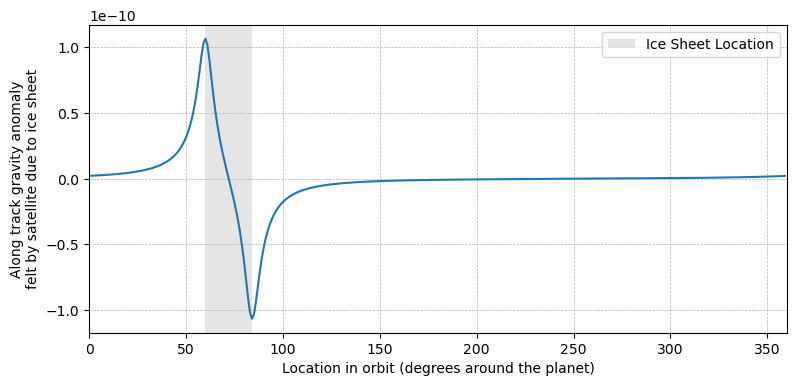

In [6]:
plt.figure(figsize=(9,4))

# plot the along track gravity anomaly
plt.plot(phi_orbit_deg, g_orbit)
ymin, ymax = plt.gca().get_ylim()

# plot the location of the ice sheet
rect = Rectangle((np.rad2deg(phi_G1), ymin),
                 np.rad2deg(phi_G2-phi_G1), ymax-ymin,
                 facecolor='silver', alpha=0.4, label='Ice Sheet Location')
plt.gca().add_patch(rect)

# label the axes
plt.ylabel('Along track gravity anomaly\nfelt by satellite due to ice sheet')
plt.xlabel('Location in orbit (degrees around the planet)') 
plt.xlim([0,360])
plt.grid(linestyle='--',linewidth=0.5)
plt.legend()
plt.show()

As we can see in the plot above, the gravity anomaly increases as the satellite approaches the ice sheet. As it passes over the ice sheet, the gravity anomaly starts to decline as some portions of the ice sheet are now behind the satellite, pulling it in the reverse direction. The anomaly is most negative at the satellite leaves the ice sheet (the ice shee is directly behind the satellite). The anomaly is zero when the satellite is on the opposite side of the planet as the center of the ice sheet.

## Relative acceleration of the GRACE satellite pair

The GRACE pair of satellite leverages the distance between them to infer small changes in acceleation due to gravity. Nominally, the satellites are spaced by a distance of 220 km. Let's determine what that distance is in radians:

In [7]:
# angular separation in radians
alpha = L_0/(R+h)

We can use this information and out function above to compute the along-track gravity anomalies of the two satellites and then their relative acceleration:

$$
a_{rel} = g_{1,along}(\phi_s) -  g_{2,along}(\phi_s-\alpha)
$$

In [8]:
# along-track gravity anomalues for each satellite
g_orbit_1 = along_track_gravity(phi_orbit)       # leading
g_orbit_2 = along_track_gravity(phi_orbit-alpha) # trailing

# relative acceleration between the two satellites
a_rel = g_orbit_1 - g_orbit_2

Let's have a look:

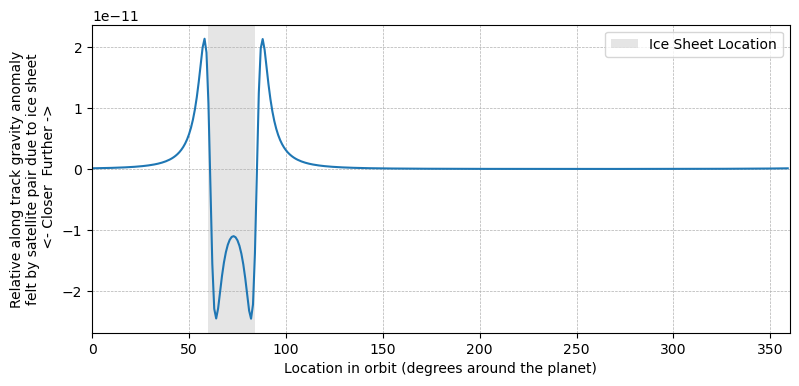

In [9]:
plt.figure(figsize=(9,4))

# plot the along track gravity anomaly
plt.plot(phi_orbit_deg, a_rel)
ymin, ymax = plt.gca().get_ylim()

# plot the location of the ice sheet
rect = Rectangle((np.rad2deg(phi_G1), ymin),
                 np.rad2deg(phi_G2-phi_G1), ymax-ymin,
                 facecolor='silver', alpha=0.4, label='Ice Sheet Location')
plt.gca().add_patch(rect)

# label the axes
plt.ylabel('Relative along track gravity anomaly\nfelt by satellite pair due to ice sheet\n <- Closer  Further ->')
plt.xlabel('Location in orbit (degrees around the planet)') 
plt.xlim([0,360])
plt.grid(linestyle='--',linewidth=0.5)
plt.legend()
plt.show()

## Inter-Satellite Distance

Next up, we'll use the relative distance between the two satellites using the inter-satellite differences. We'll do by computing the incremental addition to the distance in each degree of the orbit.

### Change in distance betweeen $\phi=0$ and $\phi=1$

Consider the change in distance between the satellites between $\phi=0$ and $\phi=1$. The distance will change according to the acceleration i.e.

$$
\frac{d^2 \Delta L}{dt^2} = a_{rel}
$$

We can recover $\Delta L$ by intergrating. In the first integration, we get

$$
\frac{d \Delta L}{dt} = \int_{\phi=0}^{\phi=1} \frac{d^2 \Delta L}{dt^2} dt = \int_{\phi=0}^{\phi=1} a_{rel} \,dt= a_{rel}\Delta t + C_1
$$

The change in time $\Delta t$ is the time to travel from $\phi=0$ to $\phi_1$, computed as the fraction of the orbit traveled divided by the satellite rate:

$$
\Delta t = \frac{2 \pi (R+h)}{360 v_s } 
$$

The constant $C_1$ is the rate at which $\Delta L$ is changing at $\phi=0$. We will assume that this is 0 for the first step of the orbit.

Next, we integrate one more time $$
\Delta L =  \int_{\phi=0}^{\phi=1} \frac{d \Delta L}{dt} dt = \int_{\phi=0}^{\phi=1} a_{rel}\Delta t \,dt= \frac{1}{2} a_{rel}\Delta t^2 + C_2
$$

Here, $C_2$ is the value of $\Delta L$ at $\phi=0$. We will assume this is 0 as well for the first timestep (i.e. its the reference for future timesteps.

### Change in distance betweeen $\phi=1$ and $\phi=2$

Next, onsider the change in distance between the satellites between $\phi=1$ and $\phi=2$. The distance will change according to the acceleration i.e.

Again, we can recover $\Delta L$ by intergration. In the first integration, we get

$$
\frac{d \Delta L}{dt} = \int_{\phi=1}^{\phi=2} \frac{d^2 \Delta L}{dt^2} dt = \int_{\phi=1}^{\phi=2} a_{rel} \,dt= a_{rel}\Delta t + C_1
$$

Now, the constant $C_1$ is the rate at which $\Delta L$ is changing at $\phi=1$. This has changed since the first step in the orbit, i.e.

$$
\frac{d \Delta L}{dt} \bigg|_{\phi=1} = a_{rel}\Delta t
$$

so

$$
\frac{d \Delta L}{dt} = a_{rel}\Delta t + a_{rel}\Delta t
$$

Next, we integrate one more time $$
\Delta L =  \int_{\phi=1}^{\phi=2} \frac{d \Delta L}{dt} dt = \int_{\phi=1}^{\phi=2} (a_{rel}\Delta t + a_{rel}\Delta t) \,dt= a_{rel}\Delta t + \frac{1}{2} a_{rel}\Delta t^2 + C_2
$$

Here, $C_2$ is the value of $\Delta L$ at $\phi=1$. We will assume this is 0 as well for the first timestep (i.e. its the reference for future timesteps.

### Generalized Algorithm

$$
\begin{align*}
\frac{d\Delta L}{dt}\bigg|_{\phi=n+1} &=  \frac{d\Delta L}{dt}\bigg|_{\phi=n} + a_{rel,n} \Delta t \\\
\Delta L_{n+1} &=\Delta L_{n} + \frac{d\Delta L}{dt}\bigg|_{\phi=n} + \frac{1}{2} a_{rel,n}\Delta t^2
\end{align*}
$$

Let's compute that here inside a function:

In [10]:
def compute_change_in_satellite_distance(phi_orbit, a_rel, delta_t):
    # make some empty arrays
    delta_L_dot = np.zeros_like(phi_orbit)
    delta_L = np.zeros_like(phi_orbit)
    
    # compute the delta Ls according to the 
    for ll in range(len(delta_L)-1):
        delta_L_dot[ll+1] = delta_L_dot[ll] + a_rel[ll]*delta_t
        delta_L[ll+1] = delta_L[ll] + delta_L_dot[ll]*delta_t + 0.5*a_rel[ll]*delta_t**2

    return(delta_L)

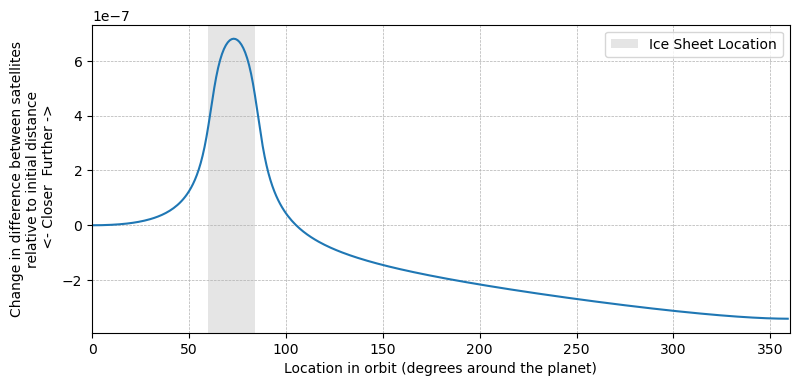

In [11]:
# compute delta L 
delta_t = (2*np.pi*(R+h)/(360*v_s))
delta_L = compute_change_in_satellite_distance(phi_orbit, a_rel, delta_t)

plt.figure(figsize=(9,4))

# plot the along track distance differences
plt.plot(phi_orbit_deg, delta_L)
ymin, ymax = plt.gca().get_ylim()

# plot the location of the ice sheet
rect = Rectangle((np.rad2deg(phi_G1), ymin),
                 np.rad2deg(phi_G2-phi_G1), ymax-ymin,
                 facecolor='silver', alpha=0.4, label='Ice Sheet Location')
plt.gca().add_patch(rect)

# label the axes
plt.ylabel('Change in difference between satellites\nrelative to initial distance\n <- Closer  Further ->')
plt.xlabel('Location in orbit (degrees around the planet)') 
plt.xlim([0,360])
plt.grid(linestyle='--',linewidth=0.5)
plt.legend()
plt.show()

We can see in the above plot that the differences are not symmetrical around the ice sheet.

### Inter-satellite differences after mass loss

Using the same approach as above, we can compute how the profiles would change if the ice sheet thins. This was implemented in the previous function so we can repeat our calculations as above:

In [12]:
# compute the gravity anomalies
g_orbit_1_after = along_track_gravity(phi_orbit, delta_H_ice=-10)     
g_orbit_2_after = along_track_gravity(phi_orbit-alpha, delta_H_ice=-10)

# compute the relative acceleration
a_rel_after = g_orbit_1_after - g_orbit_2_after

# compute the distances
delta_L_after = compute_change_in_satellite_distance(phi_orbit, a_rel_after, delta_t)

As we might expect, this looks similar to the previous plot:

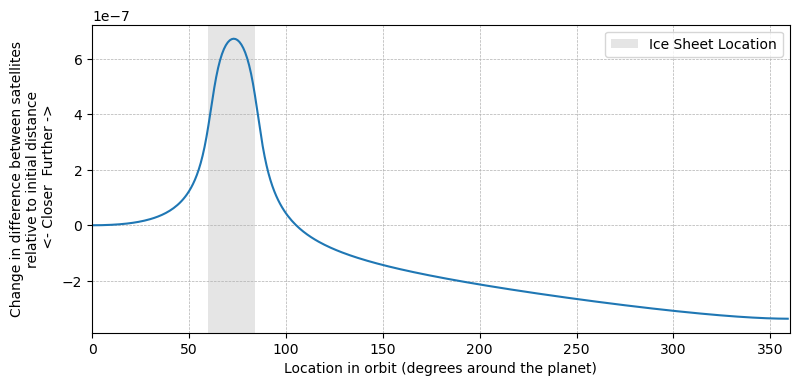

In [13]:
# compute delta L 
plt.figure(figsize=(9,4))

# plot the along track distance differences
plt.plot(phi_orbit_deg, delta_L_after)
ymin, ymax = plt.gca().get_ylim()

# plot the location of the ice sheet
rect = Rectangle((np.rad2deg(phi_G1), ymin),
                 np.rad2deg(phi_G2-phi_G1), ymax-ymin,
                 facecolor='silver', alpha=0.4, label='Ice Sheet Location')
plt.gca().add_patch(rect)

# label the axes
plt.ylabel('Change in difference between satellites\nrelative to initial distance\n <- Closer  Further ->')
plt.xlabel('Location in orbit (degrees around the planet)') 
plt.xlim([0,360])
plt.grid(linestyle='--',linewidth=0.5)
plt.legend()
plt.show()

However, we can ensure that there are indeed differences by plotting the two:

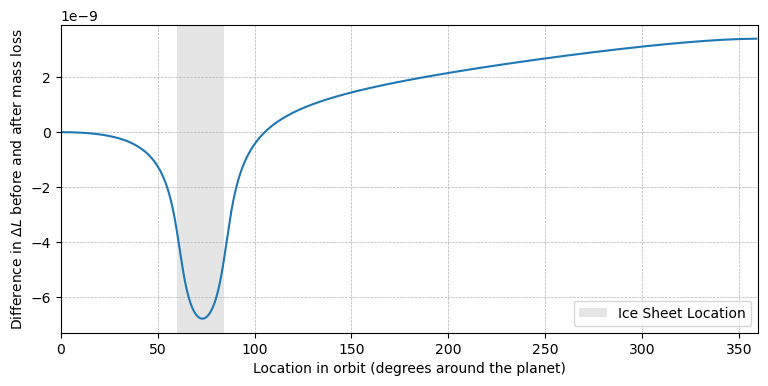

In [14]:
# compute delta L 
plt.figure(figsize=(9,4))

# plot the along track distance differences
plt.plot(phi_orbit_deg, delta_L_after-delta_L)
ymin, ymax = plt.gca().get_ylim()

# plot the location of the ice sheet
rect = Rectangle((np.rad2deg(phi_G1), ymin),
                 np.rad2deg(phi_G2-phi_G1), ymax-ymin,
                 facecolor='silver', alpha=0.4, label='Ice Sheet Location')
plt.gca().add_patch(rect)

# label the axes
plt.ylabel('Difference in $\\Delta L$ before and after mass loss')
plt.xlabel('Location in orbit (degrees around the planet)') 
plt.xlim([0,360])
plt.grid(linestyle='--',linewidth=0.5)
plt.legend()
plt.show()

As we can see, there are differences here - measured in nanometers! These extremely small differences in the satellite distances can be used to infer mass loss from the ice sheet - we'll do this calculation in the next notebook. Before we do, let's write out the data to a file we can read into the next notebook.

In [15]:
np.savetxt('delta_L_before_change.csv', np.column_stack([phi_orbit, delta_L]), delimiter=',')

In [18]:
np.savetxt('delta_L_after_change.csv', np.column_stack([phi_orbit, delta_L_after]), delimiter=',')